<a href="https://colab.research.google.com/github/shalini2006official/Snowflake/blob/main/heart_classification_using_decision_tree(snowflake).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install snowflake-connector-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 133.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found

In [ ]:
import pandas as pd
import snowflake.connector

conn = snowflake.connector.connect(
    user = 'Shalini',
    password = 'Muralidharan@23',
    account = 'TYGAIHC-RM65629',
    database = 'HEART',
    schema = 'PUBLIC',
    warehouse = 'COMPUTE_WH'
)

In [ ]:
query = "SELECT * from heart"
df = pd.read_sql(query,conn)
df

/tmp/ipykernel_3115/3694970747.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [ ]:
df.head()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.tail()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       1025 non-null   int64  
 1   SEX       1025 non-null   int64  
 2   CP        1025 non-null   int64  
 3   TRESTBPS  1025 non-null   int64  
 4   CHOL      1025 non-null   int64  
 5   FBS       1025 non-null   int64  
 6   RESTECG   1025 non-null   int64  
 7   THALACH   1025 non-null   int64  
 8   EXANG     1025 non-null   int64  
 9   OLDPEAK   1025 non-null   float64
 10  SLOPE     1025 non-null   int64  
 11  CA        1025 non-null   int64  
 12  THAL      1025 non-null   int64  
 13  TARGET    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       1025 non-null   int64  
 1   SEX       1025 non-null   int64  
 2   CP        1025 non-null   int64  
 3   TRESTBPS  1025 non-null   int64  
 4   CHOL      1025 non-null   int64  
 5   FBS       1025 non-null   int64  
 6   RESTECG   1025 non-null   int64  
 7   THALACH   1025 non-null   int64  
 8   EXANG     1025 non-null   int64  
 9   OLDPEAK   1025 non-null   float64
 10  SLOPE     1025 non-null   int64  
 11  CA        1025 non-null   int64  
 12  THAL      1025 non-null   int64  
 13  TARGET    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.shape

(1025, 14)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.tree import DecisionTreeClassifier

In [ ]:
df.isnull().sum()

,0
AGE,0
SEX,0
CP,0
TRESTBPS,0
CHOL,0
FBS,0
RESTECG,0
THALACH,0
EXANG,0
OLDPEAK,0


In [ ]:
from scipy.stats import zscore
z_scores = zscore(df)
df[np.abs(z_scores)>2.5]

NameError: name 'df' is not defined

In [ ]:
cols = ['TRESTBPS', 'CHOL','THALACH']

lower = df[cols].quantile(0.05)
upper = df[cols].quantile(0.05)

df[cols] = df[cols].clip(lower=lower, upper=upper, axis=1)

In [ ]:
df

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,52,1,0,108.0,175,0,1,108,0,1.0,2,2,3,0
1,53,1,0,108.0,175,1,0,108,1,3.1,0,0,3,0
2,70,1,0,108.0,175,0,1,108,1,2.6,0,0,3,0
3,61,1,0,108.0,175,0,1,108,0,0.0,2,1,3,0
4,62,0,0,108.0,175,1,1,108,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,108.0,175,0,1,108,1,0.0,2,0,2,1
1021,60,1,0,108.0,175,0,0,108,1,2.8,1,1,3,0
1022,47,1,0,108.0,175,0,0,108,1,1.0,1,1,2,0
1023,50,0,0,108.0,175,0,0,108,0,0.0,2,0,2,1


{'whiskers': [<matplotlib.lines.Line2D at 0x78b93c1ccaa0>,
 'caps': [<matplotlib.lines.Line2D at 0x78b93c1ccef0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78b93c1cc890>,
 'medians': [<matplotlib.lines.Line2D at 0x78b93c1cd370>,
 'fliers': [<matplotlib.lines.Line2D at 0x78b93c1cd640>,
 'means': []}

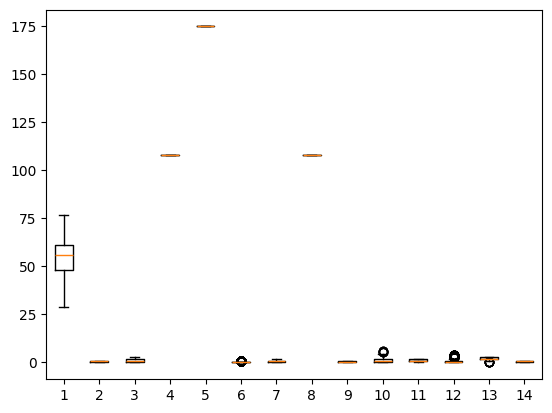

In [ ]:
plt.boxplot(df)

In [ ]:
X=df.drop('TARGET',axis=1)
y=df['TARGET']

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:

model=DecisionTreeClassifier()

In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy score:",accuracy_score(y_pred,y_test))

Accuracy score: 0.9804878048780488


In [ ]:
df.shape

NameError: name 'df' is not defined